In [85]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import gaussian_kde
from models import CondSM
from utils import f_sm, sample_X, mse_loss_normalized, normalize_over_range
import matplotlib.ticker as mtick

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print('Libraries loaded')

data_type = 'uni_1e7'
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cuda')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

cuda
Libraries loaded


<All keys matched successfully>

In [92]:
input_index_0 = 2
input_index_1 = 4

num_voltages = 7

e_0 = 1.60217663e-19
time_scale = 1e21
out_scale = e_0 * time_scale

control_indices = [c_index for c_index in range(num_voltages) if c_index not in (input_index_0,input_index_1)]
c_v_min = -1.5
c_v_max = 1.5
model = model.to(device)
with torch.no_grad():
    x = torch.zeros(4096, num_voltages, device=device)
    x.uniform_(c_v_min, c_v_max)     # or whatever voltage range you use
    y = model(x).squeeze()
    S_std = y.std().item()
    S_med = y.abs().median().item()
print("std:", S_std, "median|y|:", S_med)

#print(control_indices)
# XOR
on_volt = 0.5
gate_inputs = [
    [0.0, 0.0],
    [0.0, on_volt],
    [on_volt, 0.0],
    [on_volt, on_volt]
]

gate = 'NOR'

if gate == 'XOR':
    truth_outputs = [
        0.,
        1.,
        1.,
        0.
    ]

elif gate == 'AND':
    truth_outputs = [
        0.,
        0.,
        0.,
        1.
    ]

elif gate == 'OR':
    truth_outputs = [
        0.,
        1.,
        1.,
        1.
    ]

elif gate == 'NOR':
    truth_outputs = [
        1.,
        0.,
        0.,
        0.
    ]

elif gate == 'NAND':
    truth_outputs = [
        1.,
        1.,
        1.,
        0.
    ]

import numpy as np
import matplotlib.pyplot as plt

def plot_gate_from_currents(gate_inputs, currents, currents_sem=None, sim_currents=None, sim_sem=None):
    y = np.asarray(currents, dtype=float).reshape(-1)
    if len(y) != len(gate_inputs):
        raise ValueError("`currents` length must match gate_inputs length.")

    if currents_sem is not None:
        sem = np.asarray(currents_sem, dtype=float).reshape(-1)
        if len(sem) != len(gate_inputs):
            raise ValueError("`currents_sem` length must match gate_inputs length.")
    else:
        sem = None

    if sim_currents is not None:
        y_sim = np.asarray(sim_currents, dtype=float).reshape(-1)
        if len(y_sim) != len(gate_inputs):
            raise ValueError("`sim_currents` length must match gate_inputs length.")
    else:
        y_sim = None

    if sim_sem is not None:
        sim_sem = 1.96*np.asarray(sim_sem, dtype=float).reshape(-1)
        if len(sim_sem) != len(gate_inputs):
            raise ValueError("`sim_sem` length must match gate_inputs length.")
    else:
        sim_sem = None

    in_0 = [gi[0] for gi in gate_inputs]
    in_1 = [gi[1] for gi in gate_inputs]

    fig, axes = plt.subplots(3, 1, figsize=(6, 4), sharex=True)
    fig.subplots_adjust(left=0.22, right=0.98, bottom=0.12, top=0.98, hspace=0.15)

    labels = ["$V_0$", "$V_1$", "$I_{\\mathrm{out}} \\quad [nA]$"]
    t = np.arange(len(gate_inputs) + 1)  # 0..4

    def style_axis(ax, label):
        ax.set_ylabel(label, rotation=90.0)
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    # ---- output (mean step) ----
    y_out = np.r_[y, y[-1]]
    axes[2].step(t, y_out, where="post", lw=1, label="ground truth")

    # ---- shaded SEM band (mean ± sem) ----
    if sem is not None:
        lo = np.r_[y - sem, (y - sem)[-1]]
        hi = np.r_[y + sem, (y + sem)[-1]]
        axes[2].fill_between(t, lo, hi, step="post", alpha=0.25)

    # optional overlay: simulated
    if y_sim is not None:
        y_sim_out = np.r_[y_sim, y_sim[-1]]
        axes[2].step(t, y_sim_out, where="post", lw=2, ls="--", label="simulated")

        if sim_sem is not None:
            lo_s = np.r_[y_sim - sim_sem, (y_sim - sim_sem)[-1]]
            hi_s = np.r_[y_sim + sim_sem, (y_sim + sim_sem)[-1]]
            axes[2].fill_between(t, lo_s, hi_s, step="post", alpha=0.15)

        axes[2].legend(frameon=False, loc="best")

    style_axis(axes[2], labels[2])

    # ---- inputs ----
    y0 = np.r_[in_0, in_0[-1]]
    axes[0].step(t, y0, where="post", lw=2, c='r')
    style_axis(axes[0], labels[0])

    y1 = np.r_[in_1, in_1[-1]]
    axes[1].step(t, y1, where="post", lw=2, c='g')
    style_axis(axes[1], labels[1])

    centers = np.arange(len(gate_inputs)) + 0.5
    state_labels = ["00", "01", "10", "11"][:len(gate_inputs)]
    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(state_labels)
    axes[-1].set_xlabel("Input $V_0, V_1 \\quad [V]$")

    return axes


"""def plot_gate_from_currents(gate_inputs, currents, sim_currents=None):

    y = np.asarray(currents, dtype=float).reshape(-1)
    if len(y) != len(gate_inputs):
        raise ValueError(f"`currents` length ({len(y)}) must match gate_inputs length ({len(gate_inputs)}).")

    if sim_currents is not None:
        y_sim = np.asarray(sim_currents, dtype=float).reshape(-1)
        if len(y_sim) != len(gate_inputs):
            raise ValueError(f"`sim_currents` length ({len(y_sim)}) must match gate_inputs length ({len(gate_inputs)}).")
    else:
        y_sim = None

    in_0 = [gi[0] for gi in gate_inputs]
    in_1 = [gi[1] for gi in gate_inputs]

    fig, axes = plt.subplots(3, 1, figsize=(6, 4), sharex=True)
    fig.subplots_adjust(left=0.22, right=0.98, bottom=0.12, top=0.98, hspace=0.15)

    labels = ["$V_0$", "$V_1$", "$I_{\\mathrm{out}} \\quad [nA]$"]

    # time axis: 4 states -> 5 edges
    t = np.arange(len(gate_inputs) + 1)

    def style_axis(ax, label):
        ax.set_ylabel(label, rotation=90.0)
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    # output (ground truth)
    y_out = np.r_[y, y[-1]]
    axes[2].step(t, y_out, where="post", lw=2, label="ground truth")
    style_axis(axes[2], labels[2])

    # optional overlay: simulated currents
    if y_sim is not None:
        y_sim_out = np.r_[y_sim, y_sim[-1]]
        axes[2].step(t, y_sim_out, where="post", lw=2, ls="--", label="simulated")
        axes[2].legend(frameon=False, loc="best")

    # input 0
    y0 = np.r_[in_0, in_0[-1]]
    axes[0].step(t, y0, where="post", lw=2, c='r')
    style_axis(axes[0], labels[0])

    # input 1
    y1 = np.r_[in_1, in_1[-1]]
    axes[1].step(t, y1, where="post", lw=2, c='g')
    style_axis(axes[1], labels[1])

    # x-ticks at the middle of each interval, labeled by input combination
    centers = np.arange(len(gate_inputs)) + 0.5
    state_labels = ["00", "01", "10", "11"][:len(gate_inputs)]
    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(state_labels)
    axes[-1].set_xlabel("Input $V_0, V_1 \\quad [V]$")

    # margins
    for ax in axes:
        ymin, ymax = ax.get_ylim()
        margin = 0.1 * (ymax - ymin if ymax > ymin else 1.0)
        ax.set_ylim(ymin - margin, ymax + margin)
        #ax.set_box_aspect(1)

    return axes"""

def plot_gate(model, theta, control_indices, gate_inputs):

    input_tensor = torch.zeros(len(gate_inputs), num_voltages)
    control_voltages = torch.from_numpy(theta).float().expand(len(gate_inputs), -1)
    for j, c_idx in enumerate(control_indices):
        input_tensor[:, c_idx] = control_voltages[:, j]
    
    for k in range(len(gate_inputs)):
        input_tensor[k, input_index_0] = gate_inputs[k][0]
        input_tensor[k, input_index_1] = gate_inputs[k][1]
    input_tensor = input_tensor.to(device)

    model.eval()
    with torch.no_grad():
        y = (model(input_tensor).detach().cpu().squeeze().numpy()).tolist()
    #print(y)
    in_0 = [gate_inputs[0][0], gate_inputs[1][0], gate_inputs[2][0], gate_inputs[3][0]]
    in_1 = [gate_inputs[0][1], gate_inputs[1][1], gate_inputs[2][1], gate_inputs[3][1]]
    
    fig, axes = plt.subplots(3, 1, figsize=(6, 4), sharex=True)
    fig.subplots_adjust(left=0.22, right=0.98, bottom=0.12, top=0.98, hspace=0.15)

    labels = ["$V_0$", "$V_1$", "$I_{\mathrm{out}} \quad [nA]$"]
    
    # time axis: 4 states -> 5 edges
    t = np.arange(len(in_0) + 1)
    
    # helper: nice common style
    def style_axis(ax, label):
        ax.set_ylabel(label, rotation=90.0)#, ha="right", va="center")
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        # remove top/right spines
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
    
    # output
    y_out = np.r_[y, y[-1]]
    axes[2].step(t, y_out, where="post", lw=2)
    style_axis(axes[2], labels[2])
    
    # input 0
    y0 = np.r_[in_0, in_0[-1]]
    axes[0].step(t, y0, where="post", lw=2, c='r')
    style_axis(axes[0], labels[0])
    
    # input 1
    y1 = np.r_[in_1, in_1[-1]]
    axes[1].step(t, y1, where="post", lw=2, c='g')
    style_axis(axes[1], labels[1])
    
    # x-ticks at the middle of each interval, labeled by input combination
    centers = np.arange(len(y)) + 0.5
    state_labels = ["00", "01", "10", "11"]
    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(state_labels)
    axes[-1].set_xlabel("Input $V_0, V_1 \quad [V]$")
    
    # small margins so steps aren't glued to edges
    for ax in axes:
        ymin, ymax = ax.get_ylim()
        margin = 0.1 * (ymax - ymin if ymax > ymin else 1.0)
        ax.set_ylim(ymin - margin, ymax + margin)
        #ax.set_box_aspect(1)
    
    return axes

print('DONE')

std: 28.288558959960938 median|y|: 24.438337326049805
DONE


In [93]:
seed = 42
torch.manual_seed(seed)

num_samples = 10_000_000
#theta_samples = sample_X(num_samples, c_v_min, c_v_max, d=5)
theta_samples = torch.rand(size=(num_samples, 5)) * (c_v_max - c_v_min) + c_v_min

# Robustness settings
K = 16                # Monte-Carlo trials per theta (8–32 typical)
sigma_val = 0.025
sigma = sigma_val * S_std           # output-noise std in SAME units as model output
risk_lambda = 0.5   # robust objective: mean(fitness) - risk_lambda*std(fitness)
chunk_size = 1024      # batch thetas for speed (tune for your GPU/CPU RAM)

# Scoring constants
eps_delta = 1e-10
bonus_scale = 0.05

truth = torch.tensor(truth_outputs, device=device, dtype=torch.float32).view(1, 1, -1)  # [1,1,4]
gate_in = torch.tensor(gate_inputs, device=device, dtype=torch.float32)                  # [4,2]

model = model.to(device)
model.eval()

scores = np.empty(num_samples, dtype=np.float32)

with torch.no_grad():
    for start in range(0, num_samples, chunk_size):
        end = min(start + chunk_size, num_samples)
        B = end - start

        # theta batch: [B, d]
        # theta_b = torch.from_numpy(theta_samples[start:end]).to(device=device, dtype=torch.float32)
        theta_b = theta_samples[start:end].to(device=device, dtype=torch.float32)

        # Build input tensor for all (theta, gate_state):
        # input_b: [B, 4, num_voltages]
        input_b = torch.zeros((B, len(gate_inputs), num_voltages), device=device, dtype=torch.float32)

        # Fill control voltages
        # For each control index j, set that column for all 4 gate states
        for j, c_idx in enumerate(control_indices):
            input_b[:, :, c_idx] = theta_b[:, j].unsqueeze(1)  # [B,1] -> broadcast over 4

        # Fill the two gate input voltages for the 4 states
        input_b[:, :, input_index_0] = gate_in[:, 0].unsqueeze(0)  # [1,4]
        input_b[:, :, input_index_1] = gate_in[:, 1].unsqueeze(0)  # [1,4]

        # Forward pass in one go: reshape to [B*4, num_voltages]
        y0 = model(input_b.reshape(B * 4, num_voltages)).squeeze()
        y0 = y0.reshape(B, 4)  # [B,4]

        # Add output noise: [B,K,4]
        noise = sigma * torch.randn((B, K, 4), device=device, dtype=torch.float32)
        y = y0.unsqueeze(1) + noise

        # Per-trial min/max over the 4 gate states
        I_min = y.min(dim=2).values  # [B,K]
        I_max = y.max(dim=2).values  # [B,K]
        delta = I_max - I_min        # [B,K]

        # Handle near-constant outputs: set fitness to very low
        valid = delta.abs() >= eps_delta  # [B,K]

        # Normalize currents to [0,1] per trial: (y - I_min)/delta
        norm = (y - I_min.unsqueeze(2)) / (delta.unsqueeze(2) + (~valid).float().unsqueeze(2))  # safe denom
        # Compute mean absolute error vs truth over 4 states
        err = (norm - truth).abs().mean(dim=2)  # [B,K]

        F0 = 1.0 - err  # [B,K]

        denom = torch.maximum(torch.maximum(I_max.abs(), I_min.abs()), torch.tensor(eps_delta, device=device))
        bonus = bonus_scale * (delta / denom)  # [B,K]

        fitness = F0 + bonus  # [B,K]
        fitness = torch.where(valid, fitness, torch.full_like(fitness, -1e9))

        # Robust aggregate per theta: mean - lambda*std over K trials
        fit_mean = fitness.mean(dim=1)              # [B]
        fit_std  = fitness.std(dim=1, unbiased=False)  # [B]
        robust = fit_mean - risk_lambda * fit_std   # [B]

        scores[start:end] = robust.detach().cpu().numpy().astype(np.float32)

print("Done. scores shape:", scores.shape)
print("GATE: ", gate)
# Example: get best theta and its score
best_idx = int(np.argmax(scores))
best_theta = theta_samples[best_idx]
best_score = float(scores[best_idx])
print("Best idx:", best_idx, "best_score:", best_score)
print("Best theta:", best_theta.tolist())
# If you want to visualize the best solution:
# plot_gate(model, best_theta, control_indices, gate_inputs)

np.savetxt(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_{gate}_params_seed={seed}_lambda={risk_lambda}_sigma_val={sigma_val}.txt', best_theta.tolist())    
"""with open(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_{gate}_params_seed={seed}_lambda={risk_lambda}_sigma_val={sigma_val}.txt', 'a') as f:
    f.write(f"seed: {seed}\n")
    f.write(f"sigma: {sigma_val}\n")
    f.write(f"lambda: {risk_lambda}\n")"""

Done. scores shape: (10000000,)
GATE:  NOR
Best idx: 82110 best_score: 0.7434463500976562
Best theta: [-0.4169844388961792, -1.456965684890747, 0.16127896308898926, 0.57108473777771, 0.12577581405639648]


'with open(f\'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_{gate}_params_seed={seed}_lambda={risk_lambda}_sigma_val={sigma_val}.txt\', \'a\') as f:\n    f.write(f"seed: {seed}\n")\n    f.write(f"sigma: {sigma_val}\n")\n    f.write(f"lambda: {risk_lambda}\n")'

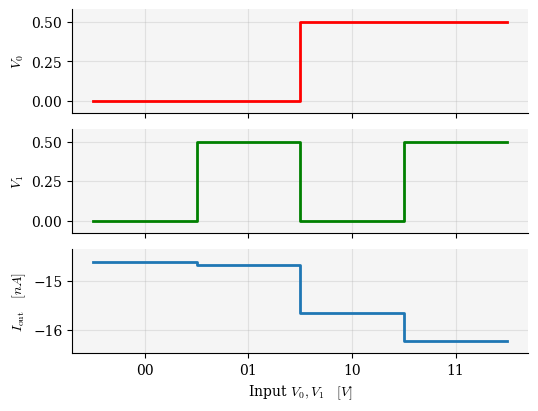

In [91]:
C = 1.602e-19
scale = 1e21

"""data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_0.0_0.0.npz')
print(data['inputs'])
#best_theta_0 = np.delete(data['inputs'], [0, input_index_0-1, input_index_1-1])
#print(best_theta_0)
#print('Device inputs:', data['inputs'])
print('Best theta:', best_theta)
best_theta = np.array([0.3063795566558838, -0.31794142723083496, 0.004651546478271484, -0.8443762063980103, -0.19127404689788818])
#best_theta = np.delete(data['inputs'], [0, input_index_0, input_index_1])
#print(best_theta)
I_00 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_0.0_0.0.npz')['current'] * scale
I_01 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_0.0_{on_volt}.npz')['current'] * scale
I_10 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_{on_volt}_0.0.npz')['current'] * scale
I_11 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_{on_volt}_{on_volt}.npz')['current'] * scale

I_00_sem = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_0.0_0.0.npz')['sem'] * scale
I_01_sem = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_0.0_{on_volt}.npz')['sem'] * scale
I_10_sem = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_{on_volt}_0.0.npz')['sem'] * scale
I_11_sem = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_{on_volt}_{on_volt}.npz')['sem'] * scale

true_Is = [I_00, I_01, I_10, I_11]
Is_sem = [I_00_sem, I_01_sem, I_10_sem, I_11_sem]
print('True Is:', true_Is)
print('Is sem:', Is_sem)"""

#min_score = min(scores)
#max_score = max(scores)
#max_index = scores.index(max_score)
#print(max_index)
#print(min_score)
#print(max_score)
"""bins = 100
fig, ax = plt.subplots()
ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(which='both', direction='in')
ax.plot(scores, bins=bins, density=True, histtype='step', cumulative=True, label=f'{gate}')
ax.grid(lw=0.5, alpha=0.5)
ax.set_xlabel(r'Fitness $F_0$')
ax.set_box_aspect(1)
ax.legend()"""
      
#best_theta = np.array([-0.18653527, -0.90552889, 1.08637776, 1.47960793, -1.31394428])#theta_samples[max_index]
    
axes_sm = plot_gate(model, best_theta.numpy(), control_indices, gate_inputs)
fig_sm = axes_sm[0].figure
#fig_sm.savefig(f'{data_type}_{gate}_sm.pdf')

#axes_kmc = plot_gate_from_currents(gate_inputs, true_Is, Is_sem)
#fig_kmc = axes_kmc[0].figure
#fig_kmc.savefig(f'{data_type}_{gate}_kmc.pdf')

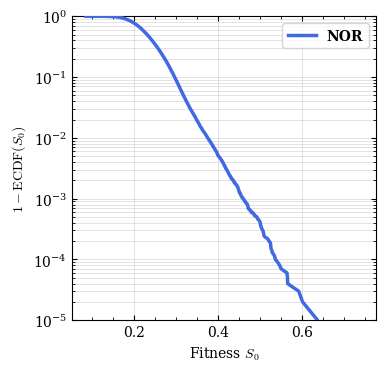

In [94]:
s = np.asarray(scores[:100_000], float)
s = s[np.isfinite(s)]
s_sorted = np.sort(s)
n = len(s_sorted)

ecdf = np.arange(1, n+1) / n
ccdf = 1 - ecdf  # P(S0 > s) approximately

fig, ax = plt.subplots(figsize=(4,4))
ax.set_position([0.18, 0.12, 0.76, 0.83])
ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(which='both', direction='in')

ax.plot(s_sorted, ccdf, lw=2.5, zorder=6, c='royalblue')
ax.set_yscale('log')
ax.set_ylim(1/n, 1)  # avoid 0 on log scale

ax.grid(lw=0.5, alpha=0.5, which='major')
ax.grid(lw=0.5, alpha=0.5, which='minor', axis='y')
ax.set_xlabel(r'Fitness $S_0$')
ax.set_ylabel(r'$1-\mathrm{ECDF}(S_0)$')
#ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))  # 0.2 -> "20%"
ax.set_box_aspect(1)
ax.legend(labels=[rf'{gate}'], prop={'weight': 'bold'})
fig.savefig(f'ccdf_gate={gate}_{data_type}_seed={seed}_risk_l={risk_lambda}_sigma={sigma_val}.pdf', bbox_inches=None, pad_inches=None)

In [ ]:
s = np.asarray(scores[:100_000], float) 
s = s[np.isfinite(s)] 
s_sorted = np.sort(s) 
y = np.arange(1, len(s_sorted)+1) / len(s_sorted) 
fig, ax = plt.subplots(figsize=(4,4)) 
ax.set_position([0.18, 0.12, 0.76, 0.83]) 
ax.minorticks_on() 
ax.tick_params(top=True, right=True, which='both') 
ax.tick_params(which='both', direction='in') 
ax.plot(s_sorted, y, lw=2., zorder=6, c='darkorange') 
ax.set_ylim(0, 1) ax.grid(lw=0.5, alpha=0.5) 
ax.set_xlabel(r'Fitness $S_0$') 
ax.set_ylabel(r'ECDF($S_0$)') 
ax.set_box_aspect(1) ax.legend(labels=[rf'{gate}'], prop={'weight': 'bold'}) fig.savefig(f'ecdf_gate={gate}_{data_type}_seed={seed}_risk_l={risk_lambda}_sigma={sigma_val}.pdf', bbox_inches='tight', pad_inches=None)

Text(0, 0.5, '$P(F_0 > x)$')

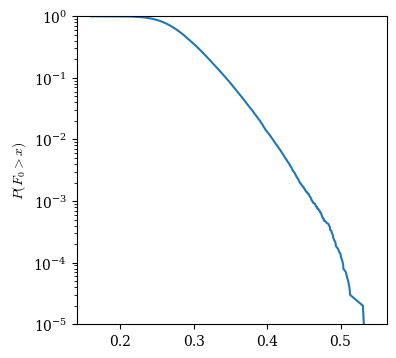

In [29]:
fig_1, ax_1 = plt.subplots(figsize=(4, 4))

y_surv = 1 - y
ax_1.plot(s_sorted, y_surv)
ax_1.set_yscale('log')
ax_1.set_ylim(1/len(s_sorted), 1)  # avoid zeros on log scale
ax_1.set_ylabel(r'$P(F_0 > x)$')

In [42]:
num_iterations = 1000

def compute_fitness(theta_param: torch.Tensor) -> torch.Tensor:
    """
    theta_param: shape (5,) – one voltage for each control index
    returns: scalar fitness (to be maximized)
    """
    # Build input tensor for the 4 gate inputs
    input_tensor = torch.zeros(len(gate_inputs), num_voltages, device=device)

    # Set control voltages
    for j, c_idx in enumerate(control_indices):
        input_tensor[:, c_idx] = theta_param[j]

    # Set logic inputs
    for k, (v0, v1) in enumerate(gate_inputs):
        input_tensor[k, input_index_0] = v0
        input_tensor[k, input_index_1] = v1

    # Forward pass
    y = model(input_tensor).squeeze(1)  # shape (4,)

    # Your normalisation and fitness calculation in torch
    I_min = y.min()
    I_max = y.max()
    delta = I_max - I_min

    # Avoid division by 0 if all currents are identical
    eps = 1e-15
    delta_safe = torch.where(delta.abs() < eps,
                             torch.full_like(delta, eps),
                             delta)

    norm_currents = (y - I_min) / delta_safe   # shape (4,)

    # Mean absolute error w.r.t truth table
    errors = (truth_tensor - norm_currents).abs()
    mean_error = errors.mean()

    F0 = 1.0 - mean_error

    # Bonus term
    denom = torch.maximum(
        torch.maximum(I_max.abs(), I_min.abs()),
        torch.tensor(eps, device=device)
    )
    bonus = 0.05 * (delta / denom)

    fitness = F0 + bonus
    return fitness

for param in model.parameters():
    param.requires_grad_(False)
model.eval()
model = model.to(device)

c_v_min = -1.5
c_v_max = 1.5
theta_vector = nn.Parameter(
    torch.empty(5, device=device).uniform_(c_v_min, c_v_max)
)
optimizer = torch.optim.Adam([theta_vector], lr=1e-2)

num_steps = 10_000  # choose how long you want to optimize

truth_tensor = torch.tensor(truth_outputs, device=device, dtype=torch.float32)
for step in range(num_steps):
    optimizer.zero_grad()

    fitness = compute_fitness(theta_vector)
    loss = -fitness  # maximize fitness

    loss.backward()
    optimizer.step()

    # Optional: clamp theta to a valid voltage range, e.g. [0, 1]
    with torch.no_grad():
        theta_vector.clamp_(c_v_min, c_v_max)

    if step % 1000 == 0:
        print(f"Step {step:5d} | fitness = {fitness.item():.6f} | theta = {theta_vector.detach().cpu().numpy()}")

best_theta = theta_vector.detach().cpu().numpy()
print(best_theta)

plot_gate(model, best_theta, control_indices, gate_inputs)

Step     0 | fitness = 0.593439 | theta = [-0.03668331 -0.84760934 -0.9159079   0.18660915  0.23306932]


KeyboardInterrupt: 